# Random Forest Classifier
Train a Random Forest on the 25 selected features using the patient-level train/test split.
Evaluate on the held-out test set using accuracy, precision, recall, F1 and ROC AUC.
Plot feature importances and compare against Mann-Whitney rankings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

PROJECT_ROOT = Path(r"D:\sop")
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"
MODELS_DIR   = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
matplotlib.rcParams.update({"font.size": 9})

print("Ready.")

Ready.


In [2]:
# loading train and test splits

train = pd.read_csv(SPLITS_DIR / "train.csv")
test  = pd.read_csv(SPLITS_DIR / "test.csv")

print(f"Train: {len(train)} recordings  (absent={len(train[train['class']=='absent'])}, present={len(train[train['class']=='present'])})")
print(f"Test : {len(test)} recordings  (absent={len(test[test['class']=='absent'])}, present={len(test[test['class']=='present'])})")

Train: 3785 recordings  (absent=1894, present=1891)
Test : 997 recordings  (absent=497, present=500)


In [3]:
# preparing features and labels
# dropping file and class columns to get feature matrix X
# encoding labels: absent = 0, present = 1

FEATURE_COLS = [c for c in train.columns if c not in ["file", "class"]]

X_train = train[FEATURE_COLS].values
y_train = (train["class"] == "present").astype(int).values

X_test  = test[FEATURE_COLS].values
y_test  = (test["class"] == "present").astype(int).values

print(f"Feature matrix shape  train: {X_train.shape}")
print(f"Feature matrix shape  test : {X_test.shape}")
print(f"Label encoding        absent=0, present=1")
print(f"Train labels          0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")
print(f"Test labels           0: {(y_test==0).sum()}  1: {(y_test==1).sum()}")

Feature matrix shape  train: (3785, 25)
Feature matrix shape  test : (997, 25)
Label encoding        absent=0, present=1
Train labels          0: 1894  1: 1891
Test labels           0: 497  1: 500


In [4]:
# training the Random Forest
# n_estimators=300      : 300 trees, stable and robust
# min_samples_leaf=5    : each leaf needs at least 5 samples, prevents overfitting
# class_weight=balanced : corrects for class imbalance automatically
# n_jobs=-1             : uses all CPU cores

rf = RandomForestClassifier(
    n_estimators     = 300,
    min_samples_leaf = 5,
    class_weight     = "balanced",
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)

rf.fit(X_train, y_train)
print("Training complete.")
print(f"Number of trees         : {rf.n_estimators}")
print(f"Number of features used : {rf.n_features_in_}")

Training complete.
Number of trees         : 300
Number of features used : 25


In [5]:
# evaluating on the test set

y_pred = (rf.predict_proba(X_test)[:, 1] >= 0.35).astype(int)
y_pred_prob = rf.predict_proba(X_test)[:, 1]  # probability of present

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["absent", "present"]))

Accuracy : 0.6229  (62.29%)
ROC AUC  : 0.7011

Classification report:
              precision    recall  f1-score   support

      absent       0.65      0.52      0.58       497
     present       0.60      0.73      0.66       500

    accuracy                           0.62       997
   macro avg       0.63      0.62      0.62       997
weighted avg       0.63      0.62      0.62       997



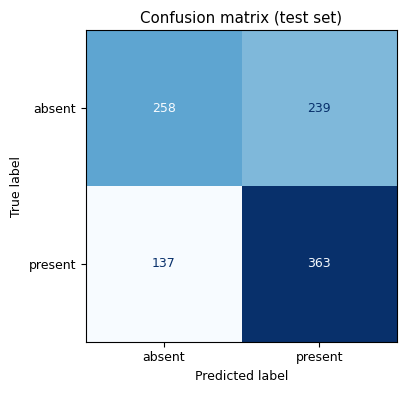

Saved: D:\sop\outputs\rf_confusion_matrix.png

True negatives  (absent correctly identified) : 258
False positives (absent called present)        : 239
False negatives (present missed)               : 137
True positives  (present correctly identified) : 363


In [6]:
# confusion matrix
# rows = actual class, columns = predicted class

cm  = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["absent", "present"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
out = OUTPUTS_DIR / "rf_confusion_matrix.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue negatives  (absent correctly identified) : {tn}")
print(f"False positives (absent called present)        : {fp}")
print(f"False negatives (present missed)               : {fn}")
print(f"True positives  (present correctly identified) : {tp}")

Feature importances (Random Forest):
              feature  importance
   u4_kraskov_entropy    0.097971
   u3_kraskov_entropy    0.070998
              u4_kurt    0.059132
    u4_sample_entropy    0.050175
               omega2    0.050100
   u2_kraskov_entropy    0.041020
              u3_kurt    0.038874
               u3_var    0.038866
u4_spectral_bandwidth    0.037672
               u4_var    0.037077
              u2_kurt    0.036616
            u3_energy    0.035940
    v_total_variation    0.034853
               omega1    0.034643
    u3_sample_entropy    0.034493
            u4_energy    0.034232
               u2_var    0.033872
            u2_energy    0.033362
          v_jump_mean    0.030788
              u1_kurt    0.029566
               u1_var    0.029421
   u1_kraskov_entropy    0.029160
             v_energy    0.027707
            u1_energy    0.027600
          v_num_jumps    0.025863


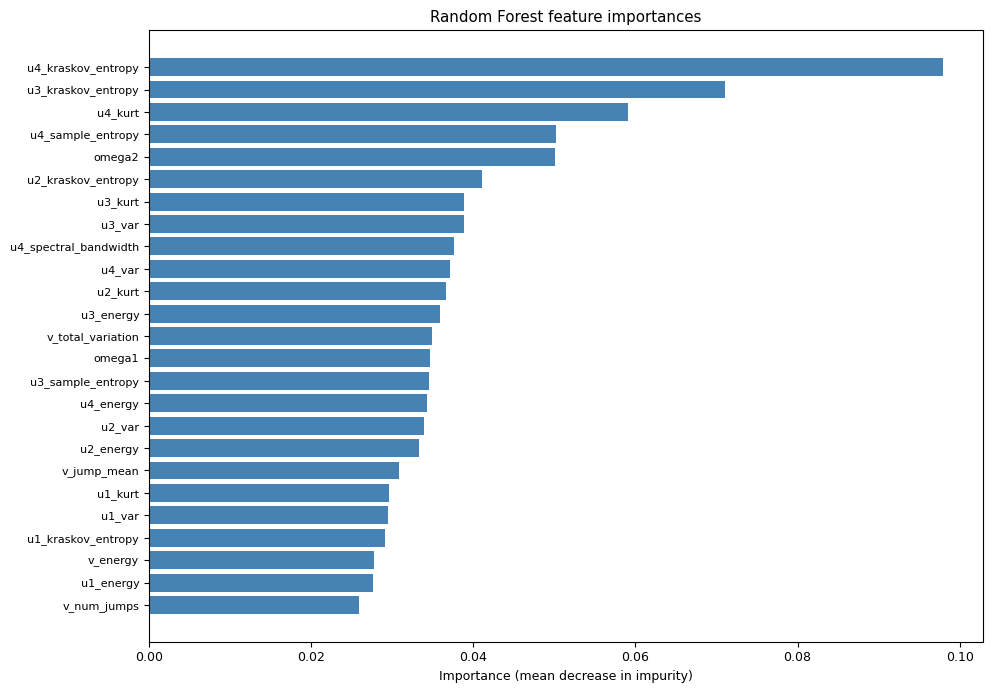

Saved: D:\sop\outputs\rf_feature_importances.png


In [7]:
# feature importances from the Random Forest
# comparing against Mann-Whitney effect_r rankings from feature analysis

importances = pd.DataFrame({
    "feature"   : FEATURE_COLS,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("Feature importances (Random Forest):")
print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importances["feature"][::-1], importances["importance"][::-1], color="steelblue", edgecolor="none")
ax.set_xlabel("Importance (mean decrease in impurity)")
ax.set_title("Random Forest feature importances")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
out = OUTPUTS_DIR / "rf_feature_importances.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [8]:
# saving the trained model

model_out = MODELS_DIR / "random_forest.joblib"
joblib.dump(rf, model_out)
print(f"Saved: {model_out}")

Saved: D:\sop\models\random_forest.joblib
